In [45]:
import ctypes
from ctypes import c_char_p, POINTER, c_double

In [46]:
lib = ctypes.CDLL("./secrets/spg4lib.so")  # not public

lib.lib_parse_lines.argtypes = [c_char_p, c_char_p]
lib.lib_parse_lines.restype = None

lib.lib_get_rv_for_date.argtypes = [ctypes.c_long, POINTER(c_double), POINTER(c_double)]
lib.lib_get_rv_for_date.restype = None

lib.lib_get_rv.argtypes = [ctypes.c_double, POINTER(c_double), POINTER(c_double)]
lib.lib_get_rv.restype = None

In [47]:

# Setup for the C code 

def parse_lines(line1, line2):
    lib.lib_parse_lines(line1.encode('utf-8'), line2.encode('utf-8'))

def get_rv_for_date(millis_since_1970):
    r = (c_double * 3)()
    v = (c_double * 3)()
    lib.lib_get_rv_for_date(millis_since_1970, r, v)
    return [r[i] for i in range(3)], [v[i] for i in range(3)]

def get_rv(minutes_after_epoch):
    r = (c_double * 3)()
    v = (c_double * 3)()
    lib.lib_get_rv(minutes_after_epoch, r, v)
    return [r[i] for i in range(3)], [v[i] for i in range(3)]

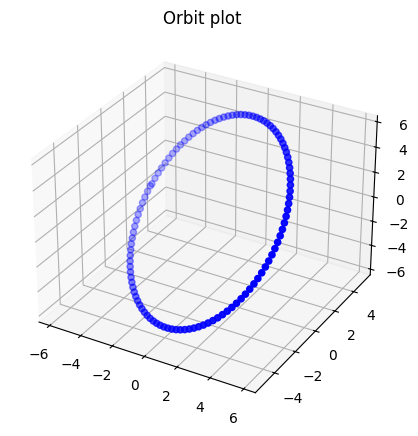

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sgp4.api import Satrec
from datetime import datetime, timedelta
from sgp4.api import jday

# TLE data for ISS
line1 = "1 25544U 98067A   19343.69339541  .00001764  00000-0  38792-4 0  9991"
line2 = "2 25544  56.6439 211.2001 0007417  17.6667  85.6398 15.50103472202482"

# Create the satellite record
satellite = Satrec.twoline2rv(line1, line2)

# Simulation values 
h = 50  # seconds, huge timestep (probably not acceptable?)
t_final = 92*60  # about 90 minutes for one orbit
steps = t_final // h

# Prepare time array
start_time = datetime(2025, 1, 1, 0, 0, 0)
t_orbit = np.linspace(0, t_final, steps)
t_orbit = np.array([start_time + timedelta(seconds=i) for i in t_orbit])

# Result array 
x_orbit = np.zeros((steps, 3))

for i, t in enumerate(t_orbit):
    jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
    e, r, v = satellite.sgp4(jd, fr)

    if e == 0:
        x_orbit[i] = r
    else:
        print("error")
        break
    
x_orbit /= 1000


fig3d = plt.figure(figsize=(6, 5))
ax = fig3d.add_subplot(111, projection="3d")
ax.scatter(x_orbit[:, 0], x_orbit[:, 1], x_orbit[:, 2], c="b", marker="o")
ax.set_title("Orbit plot")
plt.show()

[-3.11772496 -1.6594459   4.52178468]
[-5.80589642  3.06968162 -1.6240282 ]


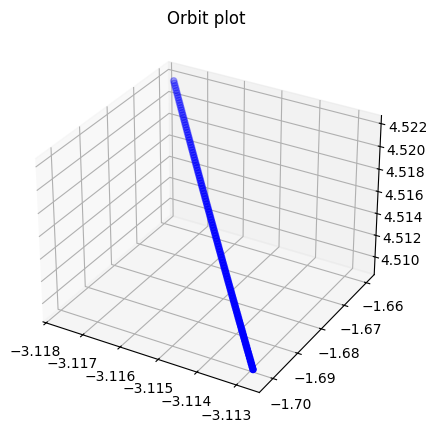

In [53]:
parse_lines(line1, line2)

start_time = datetime(2025, 1, 1, 0, 0, 0).timestamp()
t_orbit = np.linspace(0, t_final, steps)
t_orbit = np.array([int(start_time + t) for t in t_orbit])
x_orbit_c = np.zeros((steps, 3))


for i, t in enumerate(t_orbit):
  r, v = get_rv_for_date(t)
  x_orbit_c[i] = r

x_orbit_c /= 1000

print(x_orbit_c[0])
print(x_orbit[0])

fig3d = plt.figure(figsize=(6, 5))
ax = fig3d.add_subplot(111, projection="3d")
ax.scatter(x_orbit_c[:, 0], x_orbit_c[:, 1], x_orbit_c[:, 2], c="b", marker="o")
ax.set_title("Orbit plot")
plt.show()
